In [1]:
# 통계분석

# 1.회귀분석 (연속형 독립변수 1개, 종속변수 1개로 구성된 보스턴 집값 데이터 세트)
# (1) 데이터를 8:2로 분할하고 선형회귀를 적용하시오. 결정계수와 RMSE를 구하시오.
# (2) 데이터를 8:2로 분할하고 릿지회귀를 적용하시오. alpha값을 0부터 1까지 0.1단위로 모두 탐색해서
# 결정계수가 가장 높을떄의 알파를 찾고, 해당 알파로 다시 모델을 학습해서 결정계수와 rmse를 계산하시오.
# (3) 데이터를 8:2로 분할하고 라쏘 회귀를 적용하시오. alpha값을 0부터 1까지 0.1단위로 모두 탐색해서
# 결정계수가 가장 높을때의 알파를 찾고, 해당 알파로 다시 모델을 학습해서 결정계수와 rmse를 계산하시오.

In [ ]:
# !pip install mglearn

In [3]:
# (1) 데이터를 8:2로 분할하고 선형회귀를 적용하시오. 결정계수와 RMSE를 구하시오.

import pandas as pd
import numpy as np
import mglearn

# 데이터 불러오기
X,y = mglearn.datasets.load_extended_boston()

# 훈련, 테스트 데이터 세트 분리
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.2, random_state=0)

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

print('선형회귀 결정계수:', lr.score(X_test, y_test))
print('선형회귀 RMSE:', np.sqrt(mean_squared_error(y_test, lr.predict(X_test))))

선형회귀 결정계수: 0.6158858584078691
선형회귀 RMSE: 5.592657237078684


In [4]:
# (2) 데이터를 8:2로 분할하고 릿지회귀를 적용하시오. alpha값을 0부터 1까지 0.1단위로 모두 탐색해서
# 결정계수가 가장 높을떄의 알파를 찾고, 해당 알파로 다시 모델을 학습해서 결정계수와 rmse를 계산하시오

alpha = np.arange(0, 1.1, 0.1)

ridge = Ridge()
param_grid = {'alpha':alpha}
ridge_model = GridSearchCV(ridge, param_grid)
ridge_model.fit(X_train, y_train)

print(ridge_model.best_params_)
print('릿지 회귀 결정계수:', ridge_model.score(X_test, y_test))
print('릿지 회귀 RMSE:', np.sqrt(mean_squared_error(y_test, ridge_model.predict(X_test))))

{'alpha': 0.1}
릿지 회귀 결정계수: 0.7463824108919386
릿지 회귀 RMSE: 4.544412437236699


C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.36642e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.35052e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [5]:
# (3) 데이터를 8:2로 분할하고 라쏘 회귀를 적용하시오. alpha값을 0부터 1까지 0.1단위로 모두 탐색해서
# 결정계수가 가장 높을때의 알파를 찾고, 해당 알파로 다시 모델을 학습해서 결정계수와 rmse를 계산하시오.

lasso = Lasso()
param_grid = {'alpha':alpha}
lasso_model = GridSearchCV(lasso, param_grid)
lasso_model.fit(X_train, y_train)
print('라쏘 회귀 결정계수:', lasso_model.best_estimator_.score(X_test,y_test))
print('라쏘 회귀 RMSE:', np.sqrt(mean_squared_error(y_test, lasso_model.best_estimator_.predict(X_test))))

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider i

라쏘 회귀 결정계수: 0.6901880385279786
라쏘 회귀 RMSE: 5.02269891844733


C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider i

In [6]:
# 2.다항 회귀분석 시각화

# 단순선형회귀를 다항 회귀로 3차까지 적용시켜 계수를 구하고 3차항을 적용한 모델의 스캐터 플롯과 기울기 선을 그리시오.
import pandas as pd
import numpy as np

m = 100
X = 6 * np.random.randn(m,1) - 3
y = 3 * X**3 + X**2 + 2*X + 2 + np.random.randn(m,1)
line = np.linspace(-3, 3, 100, endpoint=False).reshape(-1,1)


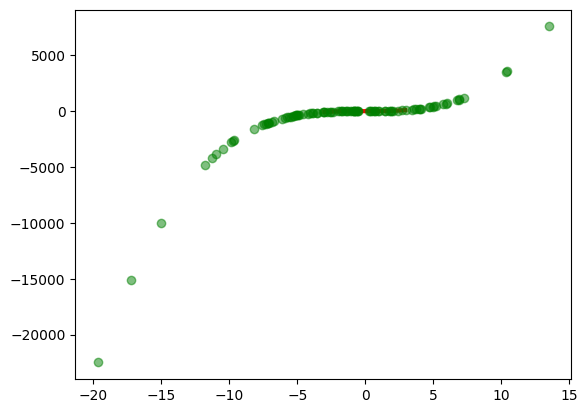

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)
poly.fit(X)
X_poly = poly.transform(X)
line_poly = poly.transform(line)
reg = LinearRegression().fit(X_poly, y)

plt.plot(line, reg.predict(line_poly), c='r', linewidth=3)
plt.plot(X, y, 'o', c='g',alpha=0.5)

In [10]:
# 3.ANOVA 분석

# 변수 3개 (하나는 범주형 변수/ 나머지 두개는 수치형 연속변수)의 이원분산분석을 수행하고 통계표를 작성하시오.

import pandas as pd 
import numpy as np

avocado = pd.read_csv('https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/avocado.csv')
avocado = avocado[['AveragePrice','type','region']]
avocado = avocado[(avocado['region']=='Orlando') |
(avocado['region']=='Boston') | (avocado['region']=='Chicago')].reset_index(drop=True)
avocado

,AveragePrice,type,region
0,1.13,conventional,Boston
1,1.07,conventional,Boston
2,1.01,conventional,Boston
3,1.02,conventional,Boston
4,1.19,conventional,Boston
...,...,...,...
1009,1.36,organic,Orlando
1010,1.67,organic,Orlando
1011,1.53,organic,Orlando
1012,1.55,organic,Orlando


In [11]:
AveragePrice = avocado['AveragePrice']
avocado_type = avocado['type']
region = avocado['region']

# 분산분석 수행
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
formula = 'AveragePrice ~ C(avocado_type)*C(region)'
model = ols(formula, avocado).fit()
aov_table = anova_lm(model, typ=2)
aov_table

,sum_sq,df,F,PR(>F)
C(avocado_type),56.111007,1.0,828.218296,1.989417e-133
C(region),0.432136,2.0,3.189242,4.161918e-02
C(avocado_type):C(region),1.878817,2.0,13.866003,1.146622e-06
Residual,68.291047,1008.0,NaN,NaN


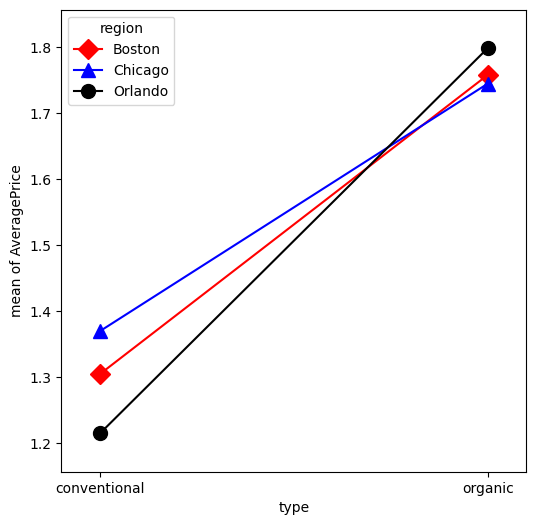

In [12]:
from statsmodels.graphics.factorplots import interaction_plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,6))
fig = interaction_plot(avocado_type, region,
                       AveragePrice, colors=['red','blue','black'], markers=['D','^','o'],
                       ms=10, ax=ax)